In [2]:
from google.colab import files

uploaded = files.upload()

Saving gateway_export.csv to gateway_export.csv
Saving merchants.csv to merchants.csv
Saving ledger.csv to ledger.csv


In [3]:
import os

print(os.listdir("/content"))

['.config', 'merchants.csv', 'gateway_export.csv', 'ledger.csv', 'sample_data']


In [4]:
import pandas as pd

ledger_df = pd.read_csv("ledger.csv")
gateway_df = pd.read_csv("gateway_export.csv")
merchants_df = pd.read_csv("merchants.csv")

print("=== DATA LOADED ===")
print("Ledger rows   :", len(ledger_df))
print("Gateway rows  :", len(gateway_df))
print("Merchants rows:", len(merchants_df))

print("\n=== LEDGER COLUMNS ===")
print(ledger_df.columns.tolist())

print("\n=== GATEWAY COLUMNS ===")
print(gateway_df.columns.tolist())

print("\n=== MERCHANT COLUMNS ===")
print(merchants_df.columns.tolist())

=== DATA LOADED ===
Ledger rows   : 547
Gateway rows  : 530
Merchants rows: 40

=== LEDGER COLUMNS ===
['transaction_id', 'user_id', 'merchant_id', 'transaction_time', 'amount_inr', 'payment_method', 'status', 'risk_score']

=== GATEWAY COLUMNS ===
['transaction_id', 'user_id', 'merchant_id', 'transaction_time', 'amount_inr', 'payment_method', 'status', 'risk_score']

=== MERCHANT COLUMNS ===
['merchant_id', 'merchant_name', 'category', 'region']


In [5]:
# ============================================
# PART D — DATA PREPARATION
# ============================================

# Convert transaction time to datetime
ledger_df["transaction_time"] = pd.to_datetime(ledger_df["transaction_time"])
gateway_df["transaction_time"] = pd.to_datetime(gateway_df["transaction_time"])

# Make sure amount is numeric
ledger_df["amount_inr"] = pd.to_numeric(ledger_df["amount_inr"])
gateway_df["amount_inr"] = pd.to_numeric(gateway_df["amount_inr"])

# Join merchant information to the ledger
ledger_analysis = ledger_df.merge(
    merchants_df[["merchant_id", "merchant_name", "category", "region"]],
    on="merchant_id",
    how="left"
)

print("=== DATA PREPARATION COMPLETE ===")
print("Ledger analysis rows:", len(ledger_analysis))
print("Missing merchant categories:", ledger_analysis["category"].isna().sum())

print("\nDate range:")
print("Start:", ledger_analysis["transaction_time"].min())
print("End  :", ledger_analysis["transaction_time"].max())

=== DATA PREPARATION COMPLETE ===
Ledger analysis rows: 547
Missing merchant categories: 0

Date range:
Start: 2026-01-01 02:14:00
End  : 2026-01-30 23:17:00


In [6]:
# ============================================
# PART D — LAYER 1: HEADLINE SCORECARDS
# ============================================

# 1. Total GMV
total_gmv = ledger_df["amount_inr"].sum()

# 2. Overall success rate
# Successful transactions are those with status = "captured"
total_transactions = len(ledger_df)
successful_transactions = (ledger_df["status"] == "captured").sum()

success_rate = successful_transactions / total_transactions


# 3. Reconciliation match rate
# A transaction matches only when:
# - transaction_id exists in BOTH files
# - amount_inr is identical
# - status is identical

ledger_compare = ledger_df[
    ["transaction_id", "amount_inr", "status"]
].copy()

gateway_compare = gateway_df[
    ["transaction_id", "amount_inr", "status"]
].copy()

comparison = ledger_compare.merge(
    gateway_compare,
    on="transaction_id",
    how="inner",
    suffixes=("_ledger", "_gateway")
)

matched_transactions = comparison[
    (comparison["amount_inr_ledger"] == comparison["amount_inr_gateway"]) &
    (comparison["status_ledger"] == comparison["status_gateway"])
]

match_rate = len(matched_transactions) / total_transactions


# 4. Chargeback ratio
chargeback_transactions = (
    ledger_df["status"] == "chargeback"
).sum()

chargeback_ratio = chargeback_transactions / total_transactions


# ============================================
# DISPLAY SCORECARDS
# ============================================

print("=" * 50)
print("          HEADLINE SCORECARDS")
print("=" * 50)

print(f"Total GMV              : INR {total_gmv:,.2f}")
print(f"Overall success rate   : {success_rate:.2%}")
print(f"Reconciliation match   : {match_rate:.2%}")
print(f"Chargeback ratio       : {chargeback_ratio:.2%}")

print("\nSupporting counts:")
print(f"Total transactions     : {total_transactions}")
print(f"Successful transactions: {successful_transactions}")
print(f"Matched transactions   : {len(matched_transactions)}")
print(f"Chargeback transactions: {chargeback_transactions}")

          HEADLINE SCORECARDS
Total GMV              : INR 382,603.00
Overall success rate   : 85.56%
Reconciliation match   : 90.49%
Chargeback ratio       : 5.12%

Supporting counts:
Total transactions     : 547
Successful transactions: 468
Matched transactions   : 495
Chargeback transactions: 28


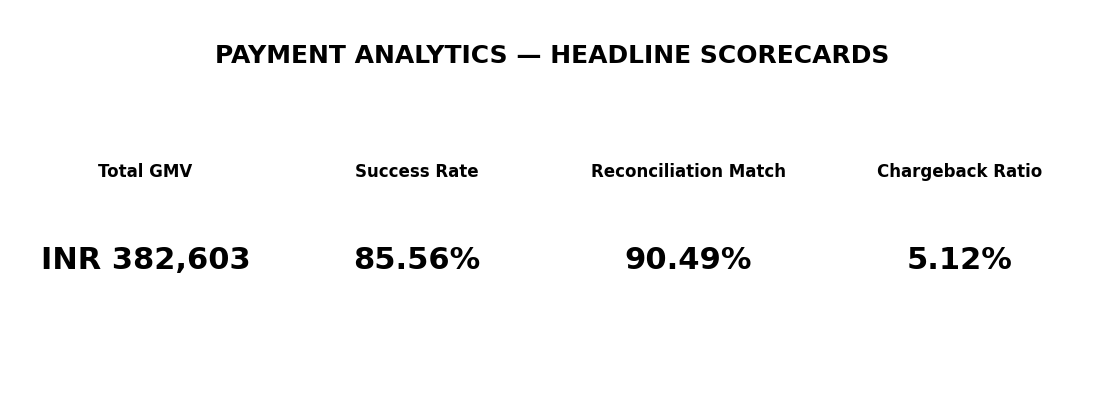

Saved: D1_headline_scorecards.png


In [7]:
# ============================================
# PART D — HEADLINE SCORECARD IMAGE
# ============================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.axis("off")

metrics = [
    ("Total GMV", f"INR {total_gmv:,.0f}"),
    ("Success Rate", f"{success_rate:.2%}"),
    ("Reconciliation Match", f"{match_rate:.2%}"),
    ("Chargeback Ratio", f"{chargeback_ratio:.2%}")
]

# Title
ax.text(
    0.5, 0.88,
    "PAYMENT ANALYTICS — HEADLINE SCORECARDS",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# Scorecards
positions = [0.125, 0.375, 0.625, 0.875]

for x, (label, value) in zip(positions, metrics):

    ax.text(
        x, 0.58,
        label,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        x, 0.35,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

# Save image
plt.savefig(
    "D1_headline_scorecards.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: D1_headline_scorecards.png")

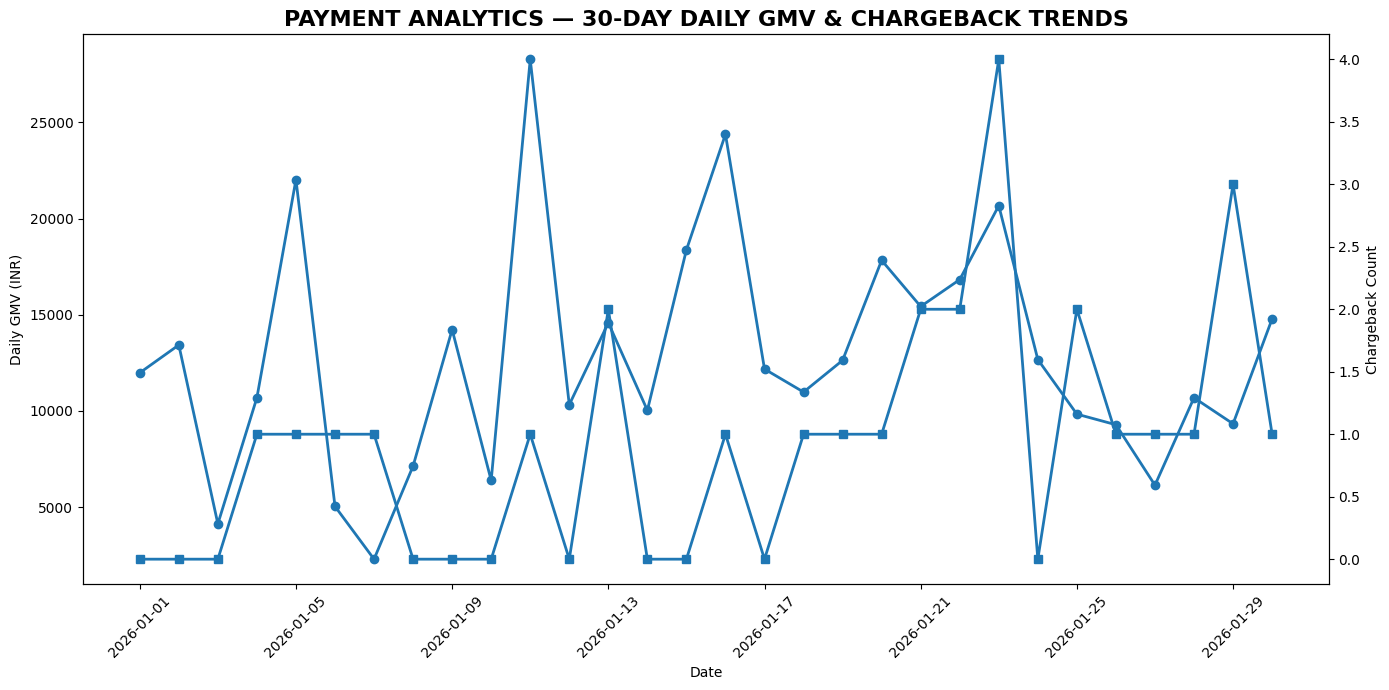

Saved: D2_trends.png

=== TRENDS SUMMARY ===
Days: 30
Total GMV: 382603
Total chargebacks: 28
Peak daily GMV: 28284
Peak daily chargebacks: 4


In [8]:
# ============================================================
# D2 — TRENDS LAYER
# Daily GMV and Daily Chargeback Count
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# Make sure transaction_time is datetime
ledger_analysis["transaction_time"] = pd.to_datetime(
    ledger_analysis["transaction_time"]
)

# Create daily date column
ledger_analysis["date"] = ledger_analysis["transaction_time"].dt.date

# Daily GMV
daily_gmv = (
    ledger_analysis
    .groupby("date")["amount_inr"]
    .sum()
)

# Daily chargeback count
daily_chargebacks = (
    ledger_analysis
    .assign(is_chargeback=ledger_analysis["status"] == "chargeback")
    .groupby("date")["is_chargeback"]
    .sum()
)

# Combine into one DataFrame
daily_trends = pd.DataFrame({
    "daily_gmv": daily_gmv,
    "daily_chargebacks": daily_chargebacks
}).fillna(0)

# Sort by date
daily_trends.index = pd.to_datetime(daily_trends.index)
daily_trends = daily_trends.sort_index()


# ============================================================
# CREATE TRENDS CHART
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 7))

# GMV line
ax1.plot(
    daily_trends.index,
    daily_trends["daily_gmv"],
    marker="o",
    linewidth=2,
    label="Daily GMV (INR)"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Daily GMV (INR)")
ax1.tick_params(axis="x", rotation=45)

# Chargeback line on second axis
ax2 = ax1.twinx()

ax2.plot(
    daily_trends.index,
    daily_trends["daily_chargebacks"],
    marker="s",
    linewidth=2,
    label="Daily Chargebacks"
)

ax2.set_ylabel("Chargeback Count")

plt.title(
    "PAYMENT ANALYTICS — 30-DAY DAILY GMV & CHARGEBACK TRENDS",
    fontsize=16,
    fontweight="bold"
)

fig.tight_layout()

# Save required chart
plt.savefig(
    "D2_trends.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: D2_trends.png")
print()
print("=== TRENDS SUMMARY ===")
print("Days:", len(daily_trends))
print("Total GMV:", daily_trends["daily_gmv"].sum())
print("Total chargebacks:", int(daily_trends["daily_chargebacks"].sum()))
print("Peak daily GMV:", daily_trends["daily_gmv"].max())
print("Peak daily chargebacks:", int(daily_trends["daily_chargebacks"].max()))

=== GMV BY PAYMENT METHOD ===


,payment_method,total_gmv
0,UPI,172274
1,Card,102429
2,Wallet,71304
3,Netbanking,36596


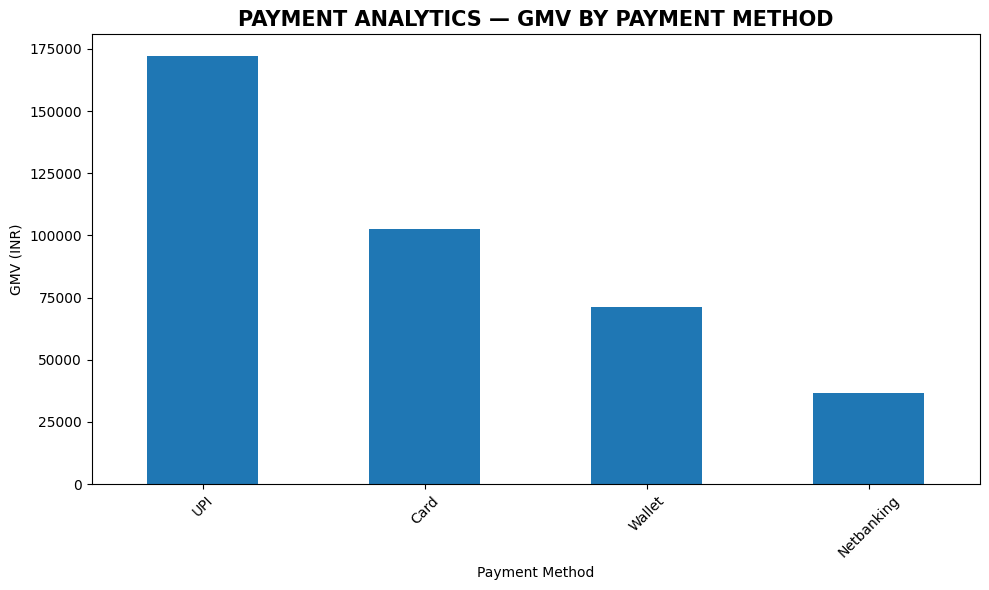

Saved: D3_gmv_by_payment_method.png

=== GMV BY CATEGORY ===


,category,total_gmv
0,ecommerce,79896
1,travel,75250
2,grocery,71936
3,food_delivery,57205
4,entertainment,56887
5,bill_payment,26304
6,recharge,15125


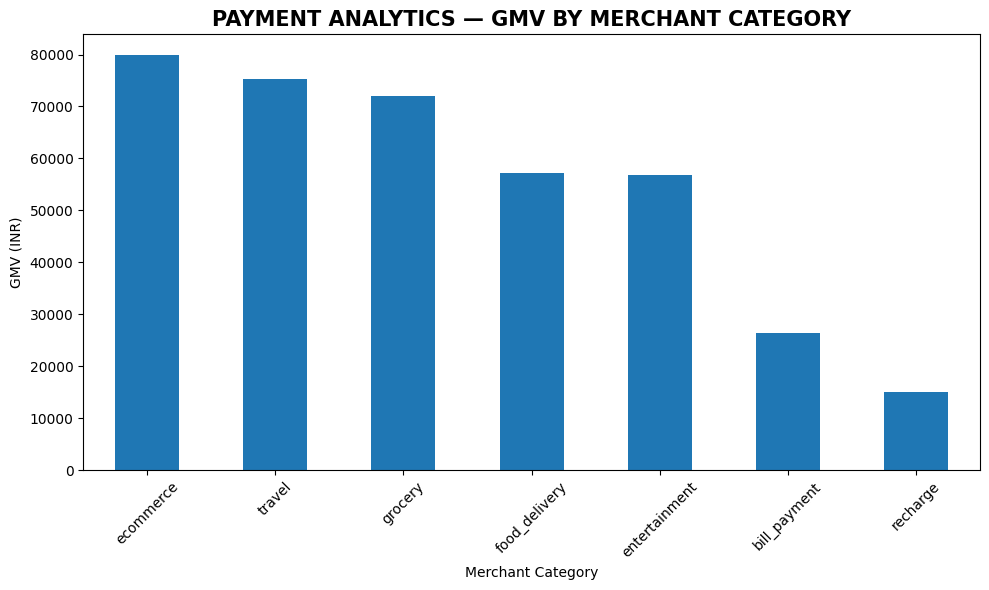

Saved: D3_gmv_by_category.png


In [9]:
# ============================================================
# D3 — BREAKDOWN LAYER
# GMV by Payment Method and GMV by Category
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. GMV BY PAYMENT METHOD
# ------------------------------------------------------------

gmv_by_payment = (
    ledger_analysis
    .groupby("payment_method")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("=== GMV BY PAYMENT METHOD ===")
display(gmv_by_payment.reset_index(name="total_gmv"))


# Create chart
plt.figure(figsize=(10, 6))

gmv_by_payment.plot(
    kind="bar",
    linewidth=1
)

plt.title(
    "PAYMENT ANALYTICS — GMV BY PAYMENT METHOD",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Payment Method")
plt.ylabel("GMV (INR)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "D3_gmv_by_payment_method.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: D3_gmv_by_payment_method.png")


# ------------------------------------------------------------
# 2. GMV BY MERCHANT CATEGORY
# ------------------------------------------------------------

gmv_by_category = (
    ledger_analysis
    .groupby("category")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("\n=== GMV BY CATEGORY ===")
display(gmv_by_category.reset_index(name="total_gmv"))


# Create chart
plt.figure(figsize=(10, 6))

gmv_by_category.plot(
    kind="bar",
    linewidth=1
)

plt.title(
    "PAYMENT ANALYTICS — GMV BY MERCHANT CATEGORY",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Merchant Category")
plt.ylabel("GMV (INR)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "D3_gmv_by_category.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: D3_gmv_by_category.png")

=== TOP 10 MERCHANTS BY TRANSACTION COUNT ===


,merchant_id,merchant_name,transaction_count,total_gmv,chargeback_count,chargeback_ratio,flag
15,16,Merchant_016,20,11130,0,0.00,
28,29,Merchant_029,19,13081,3,15.79,⚠ HIGH CHARGEBACK
36,37,Merchant_037,19,12931,1,5.26,⚠ HIGH CHARGEBACK
8,9,Merchant_009,18,4982,0,0.00,
24,25,Merchant_025,17,15533,1,5.88,⚠ HIGH CHARGEBACK
2,3,Merchant_003,17,8233,1,5.88,⚠ HIGH CHARGEBACK
29,30,Merchant_030,17,7883,0,0.00,
6,7,Merchant_007,16,15934,1,6.25,⚠ HIGH CHARGEBACK
26,27,Merchant_027,16,13584,3,18.75,⚠ HIGH CHARGEBACK
21,22,Merchant_022,16,12534,0,0.00,


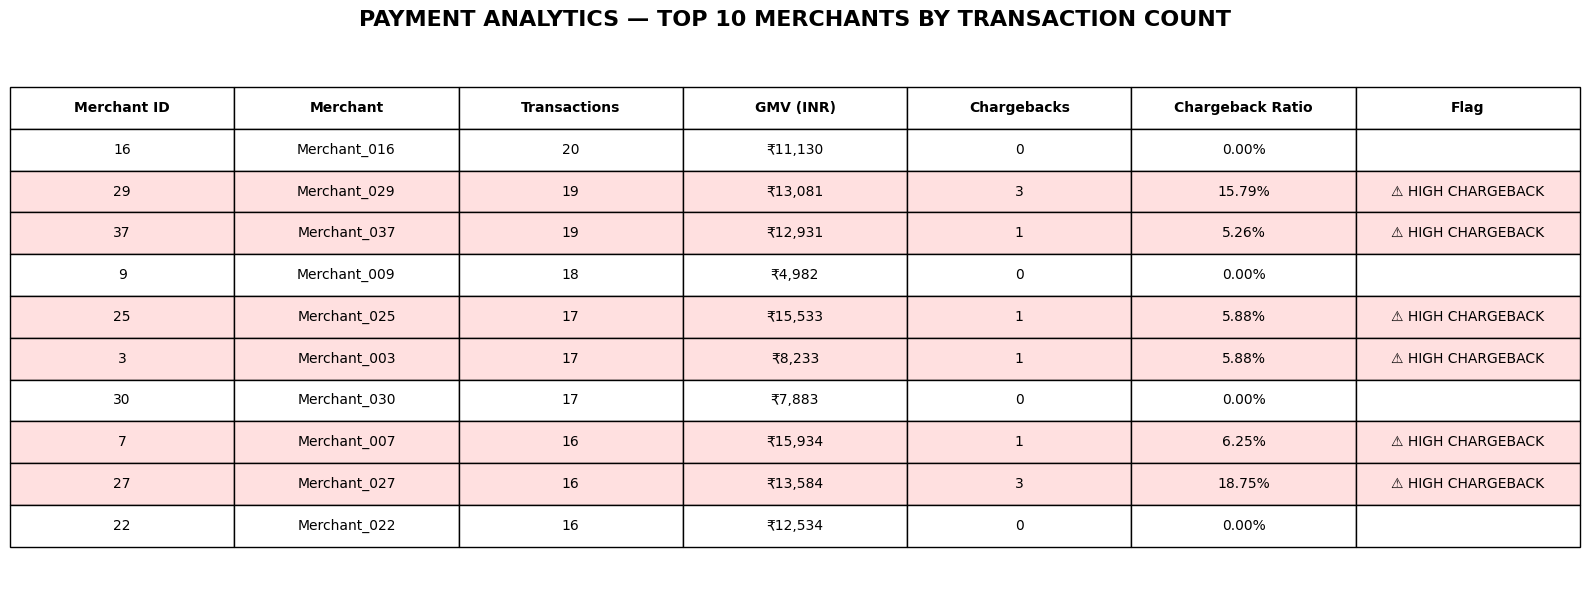

Saved: D4_merchant_details.png


In [10]:
# ============================================================
# D4 — DETAILS LAYER
# Top 10 Merchants by Transaction Count
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. CREATE MERCHANT-LEVEL SUMMARY
# ------------------------------------------------------------

merchant_details = (
    ledger_analysis
    .groupby(["merchant_id", "merchant_name"])
    .agg(
        transaction_count=("transaction_id", "count"),
        total_gmv=("amount_inr", "sum"),
        chargeback_count=("status", lambda x: (x == "chargeback").sum())
    )
    .reset_index()
)

# Per-merchant chargeback ratio
merchant_details["chargeback_ratio"] = (
    merchant_details["chargeback_count"]
    / merchant_details["transaction_count"]
)

# Flag merchants whose chargeback ratio exceeds 1%
merchant_details["flag"] = merchant_details["chargeback_ratio"].apply(
    lambda x: "⚠ HIGH CHARGEBACK" if x > 0.01 else ""
)

# ------------------------------------------------------------
# 2. TOP 10 MERCHANTS BY TRANSACTION COUNT
# ------------------------------------------------------------

top10_merchants = (
    merchant_details
    .sort_values(
        ["transaction_count", "total_gmv"],
        ascending=[False, False]
    )
    .head(10)
    .copy()
)

# Convert ratio to percentage for display
top10_display = top10_merchants.copy()

top10_display["chargeback_ratio"] = (
    top10_display["chargeback_ratio"] * 100
).round(2)

top10_display["total_gmv"] = (
    top10_display["total_gmv"].round(2)
)

top10_display = top10_display[
    [
        "merchant_id",
        "merchant_name",
        "transaction_count",
        "total_gmv",
        "chargeback_count",
        "chargeback_ratio",
        "flag"
    ]
]

print("=== TOP 10 MERCHANTS BY TRANSACTION COUNT ===")
display(top10_display)


# ------------------------------------------------------------
# 3. CREATE SAVED TABLE IMAGE
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 6))

ax.axis("off")

# Prepare table values
table_data = top10_display.copy()

table_data["total_gmv"] = table_data["total_gmv"].map(
    lambda x: f"₹{x:,.0f}"
)

table_data["chargeback_ratio"] = table_data["chargeback_ratio"].map(
    lambda x: f"{x:.2f}%"
)

table_data["transaction_count"] = table_data["transaction_count"].astype(int)
table_data["chargeback_count"] = table_data["chargeback_count"].astype(int)

# Rename columns for presentation
table_data.columns = [
    "Merchant ID",
    "Merchant",
    "Transactions",
    "GMV (INR)",
    "Chargebacks",
    "Chargeback Ratio",
    "Flag"
]

# Create table
table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# ------------------------------------------------------------
# 4. CONDITIONAL HIGHLIGHTING
# ------------------------------------------------------------

# Highlight rows where chargeback ratio > 1%
for row_idx in range(len(table_data)):

    flag_value = table_data.iloc[row_idx]["Flag"]

    if flag_value != "":
        for col_idx in range(len(table_data.columns)):
            table[(row_idx + 1, col_idx)].set_facecolor(
                "#FFE0E0"
            )

# Bold header
for col_idx in range(len(table_data.columns)):
    table[(0, col_idx)].set_text_props(weight="bold")

plt.title(
    "PAYMENT ANALYTICS — TOP 10 MERCHANTS BY TRANSACTION COUNT",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

# Save required image
plt.savefig(
    "D4_merchant_details.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: D4_merchant_details.png")

In [11]:
from google.colab import files

files.download("D1_headline_scorecards.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files

files.download("D2_trends.png")
files.download("D3_gmv_by_payment_method.png")
files.download("D3_gmv_by_category.png")
files.download("D4_merchant_details.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>